# Bài tập 3: Hồi quy Tuyến tính và KNN cho Bài toán Hồi quy
## Môn học: Trí Tuệ Nhân Tạo - EE3063

Nhóm Thực Hiện: [Điền tên thành viên nhóm]
MSSV: [Điền MSSV thành viên nhóm]

Nội dung:
1. Giới thiệu bài toán hồi quy và tạo dữ liệu mẫu.
2. Xây dựng thuật toán Hồi quy Tuyến tính (Linear Regression) từ đầu.
3. Xây dựng thuật toán K-Nearest Neighbors (KNN) cho Hồi quy từ đầu.
4. Áp dụng các thuật toán lên dữ liệu và đưa ra dự đoán mẫu.

In [1]:
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # Dùng để chia dữ liệu
from sklearn.preprocessing import StandardScaler # Chuẩn hóa dữ liệu
from sklearn.datasets import make_regression # Tạo dữ liệu mẫu cho hồi quy

## 1. Giới thiệu

Bài toán hồi quy là một dạng của học có giám sát, nơi mục tiêu là dự đoán một giá trị đầu ra liên tục (continuous value) thay vì một nhãn lớp rời rạc như trong bài toán phân loại. Ví dụ: dự đoán giá nhà, giá cổ phiếu, hoặc trong trường hợp của bài tập này là ước lượng khối lượng của một đối tượng dựa trên các đặc trưng của nó.

Trong bài tập này, chúng ta sẽ:
1.  Tự xây dựng thuật toán **Hồi quy Tuyến tính (Linear Regression)**.
2.  Tự xây dựng thuật toán **K-Nearest Neighbors (KNN) cho bài toán hồi quy (KNN Regressor)**.
3.  Áp dụng các thuật toán này trên một bộ dữ liệu mẫu.

### Yêu cầu về Dataset (HW3)

Đề bài yêu cầu "Dùng linear regression để ước lượng khối lượng của something (xoài,…..)" và "Bổ sung hw2 bang thuật toán linear regresson, sdung knn giải quyết bài toán linear regresson." Điều này gợi ý rằng chúng ta có thể sử dụng một bộ dữ liệu có cấu trúc tương tự HW2 (ví dụ: 3 đặc trưng) nhưng với mục tiêu là một biến liên tục (khối lượng).

Do mục đích minh họa thuật toán, trong notebook này, chúng ta sẽ tạo một bộ dữ liệu mẫu đơn giản gồm 3 đặc trưng và một biến mục tiêu liên tục bằng cách sử dụng hàm `make_regression` từ `sklearn.datasets`.

**LƯU Ý QUAN TRỌNG:** Khi nộp bài, nhóm cần thay thế phần tạo dữ liệu mẫu này bằng bộ dữ liệu thực tế mà nhóm đã tự thu thập (ví dụ: dữ liệu về xoài với các đặc trưng như chiều dài, chiều rộng, chu vi và khối lượng tương ứng).
"""

--- Tạo Dữ liệu Mẫu cho Bài toán Hồi quy ---
Tạo dữ liệu gồm 150 mẫu, 3 đặc trưng, và 1 biến mục tiêu.
n_informative=3 nghĩa là cả 3 đặc trưng đều có ảnh hưởng đến biến mục tiêu.

In [2]:
X_data_reg, y_data_reg = make_regression(n_samples=150,
                                         n_features=3,
                                         n_informative=3,
                                         noise=15, # Thêm nhiễu để dữ liệu thực tế hơn
                                         random_state=42)

# Chuẩn hóa đặc trưng (quan trọng cho KNN và có thể hữu ích cho Linear Regression với Gradient Descent)
scaler_reg = StandardScaler()
X_scaled_reg = scaler_reg.fit_transform(X_data_reg)

# Chia dữ liệu thành tập huấn luyện và tập kiểm thử
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_scaled_reg, y_data_reg, test_size=0.3, random_state=42)

print(f"Kích thước tập huấn luyện X: {X_train_reg.shape}, y: {y_train_reg.shape}")
print(f"Kích thước tập kiểm thử X: {X_test_reg.shape}, y: {y_test_reg.shape}")
print("\nMột vài mẫu dữ liệu X (đã chuẩn hóa):")
print(X_train_reg[:3])
print("\nMột vài giá trị y tương ứng:")
print(y_train_reg[:3])

Kích thước tập huấn luyện X: (105, 3), y: (105,)
Kích thước tập kiểm thử X: (45, 3), y: (45,)

Một vài mẫu dữ liệu X (đã chuẩn hóa):
[[-0.02948745  0.4758713  -2.30719706]
 [-0.32471338  0.03493525 -1.71236004]
 [ 0.18765175  2.28261126 -0.11271384]]

Một vài giá trị y tương ứng:
[-131.40686001 -164.54723764  159.65074202]


## 2. Hồi quy Tuyến tính (Linear Regression)

### 2.1. Giải thích Thuật toán

Hồi quy tuyến tính là một thuật toán cơ bản nhằm mô hình hóa mối quan hệ tuyến tính giữa một hoặc nhiều biến độc lập (đặc trưng - features) và một biến phụ thuộc (biến mục tiêu - target) có giá trị liên tục.

-   **Mô hình:** $y = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n = X \cdot w$
    Trong đó:
    * $y$ là giá trị dự đoán.
    * $x_1, ..., x_n$ là các đặc trưng.
    * $w_1, ..., w_n$ là các trọng số tương ứng của các đặc trưng.
    * $w_0$ là hệ số chặn (bias/intercept). Để tiện tính toán, ta có thể thêm một đặc trưng $x_0 = 1$ vào mỗi mẫu, khi đó $w_0$ trở thành một phần của vector trọng số $w$.

-   **Mục tiêu:** Tìm vector trọng số $w$ sao cho hàm mất mát (thường là Mean Squared Error - MSE) được tối thiểu.
    $MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$, với $\hat{y}_i$ là giá trị dự đoán cho mẫu $i$.

-   **Phương pháp tìm $w$ (Normal Equation):**
    Nếu ma trận $X^T X$ khả nghịch, nghiệm tối ưu cho $w$ có thể được tìm trực tiếp bằng công thức:
    $w = (X^T X)^{-1} X^T y$
    Trong đó $X$ là ma trận đặc trưng (đã thêm cột $x_0=1$) và $y$ là vector giá trị mục tiêu.
    Đây là phương pháp không cần lặp và không cần chọn learning rate.

(Tham khảo slide: "Linear regression.pdf")

Lớp LinearRegression  nhóm tự xây dựng (sử dụng Normal Equation)

In [3]:
class LinearRegressionModel:
    def __init__(self):
        self.weights = None # Sẽ lưu trữ vector trọng số w (bao gồm cả w0)

    def fit(self, X_train, y_train):
        """
        Huấn luyện mô hình Hồi quy Tuyến tính bằng Normal Equation.
        Args:
            X_train (np.array): Ma trận đặc trưng huấn luyện (chưa có cột bias).
            y_train (np.array): Vector giá trị mục tiêu huấn luyện.
        """
        n_samples, n_features = X_train.shape
        
        # Thêm cột x0 = 1 vào X_train để tính toán bias (w0)
        X_b = np.concatenate([np.ones((n_samples, 1)), X_train], axis=1)
        
        # Tính trọng số w bằng Normal Equation: w = (X_b^T * X_b)^(-1) * X_b^T * y
        try:
            # (X_b^T * X_b)
            XTX = np.dot(X_b.T, X_b)
            # (X_b^T * X_b)^(-1)
            XTX_inv = np.linalg.inv(XTX)
            # (X_b^T * X_b)^(-1) * X_b^T
            XTX_inv_XT = np.dot(XTX_inv, X_b.T)
            # w = (X_b^T * X_b)^(-1) * X_b^T * y
            self.weights = np.dot(XTX_inv_XT, y_train)
        except np.linalg.LinAlgError:
            # Xảy ra khi XTX không khả nghịch (ví dụ: các đặc trưng có tương quan tuyến tính cao)
            # Có thể dùng Pseudo-inverse hoặc Gradient Descent trong trường hợp này.
            # Ở đây ta đơn giản là báo lỗi.
            print("Lỗi: Ma trận X^T X không khả nghịch. Cân nhắc sử dụng Gradient Descent hoặc Pseudo-inverse.")
            self.weights = None # Hoặc có thể khởi tạo bằng zero

    def predict(self, X_test):
        """
        Dự đoán giá trị cho dữ liệu mới.
        Args:
            X_test (np.array): Ma trận đặc trưng của dữ liệu mới (chưa có cột bias).
        Returns:
            np.array: Vector các giá trị dự đoán.
        """
        if self.weights is None:
            raise ValueError("Mô hình chưa được huấn luyện hoặc huấn luyện lỗi. Hãy gọi hàm fit() trước.")
        
        n_samples = X_test.shape[0]
        # Thêm cột x0 = 1 vào X_test
        X_b_test = np.concatenate([np.ones((n_samples, 1)), X_test], axis=1)
        
        # Dự đoán: y_pred = X_b_test * w
        predictions = np.dot(X_b_test, self.weights)
        return predictions

## 3. K-Nearest Neighbors (KNN) cho Hồi quy (KNN Regressor)

### 3.1. Giải thích Thuật toán

KNN cũng có thể được điều chỉnh để giải quyết bài toán hồi quy.

-   **Ý tưởng chính:** Để dự đoán giá trị cho một điểm dữ liệu mới, KNN Regressor tìm kiếm $k$ điểm dữ liệu trong tập huấn luyện gần nhất với điểm đó. Thay vì lấy nhãn xuất hiện nhiều nhất (như trong phân loại), giá trị dự đoán cho điểm mới thường là **trung bình (mean)** hoặc **trung vị (median)** của các giá trị mục tiêu (target values) của $k$ láng giềng này.

-   **Các bước thực hiện khi dự đoán cho một điểm mới $x_{new}$:**
    1.  Tính khoảng cách từ $x_{new}$ đến tất cả các điểm $x_i$ trong tập huấn luyện.
    2.  Sắp xếp các khoảng cách và chọn ra $k$ điểm có khoảng cách nhỏ nhất.
    3.  Lấy các giá trị mục tiêu $y_j$ của $k$ láng giềng này.
    4.  Giá trị dự đoán cho $x_{new}$ là trung bình của các $y_j$ đó: $\hat{y}_{new} = \frac{1}{k} \sum_{j=1}^{k} y_j$.

-   **Tham số và đặc điểm:** Tương tự như KNN cho phân loại (chọn $k$, thước đo khoảng cách, chuẩn hóa dữ liệu, lazy learning).

(Tham khảo slide: "K nearest neighbors.pdf" - slide này tập trung vào phân loại, nhưng nguyên lý tìm láng giềng là tương tự. Trang 2 đề cập KNN có thể dùng cho cả classification và regression).
"""

Lớp KNNRegressor nhóm tự xây dựng

In [5]:
class KNNRegressor:
    def __init__(self, k=3):
        """
        Khởi tạo bộ hồi quy KNN.
        Args:
            k (int): Số lượng láng giềng gần nhất.
        """
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        """
        "Huấn luyện" mô hình KNN Regressor (lưu trữ dữ liệu).
        Args:
            X_train (np.array): Ma trận đặc trưng huấn luyện.
            y_train (np.array): Vector giá trị mục tiêu huấn luyện.
        """
        self.X_train = X_train
        self.y_train = y_train

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))

    def predict_single(self, x_test):
        """
        Dự đoán giá trị cho một điểm dữ liệu kiểm thử.
        Args:
            x_test (np.array): Điểm dữ liệu kiểm thử.
        Returns:
            float: Giá trị dự đoán.
        """
        if self.X_train is None or self.y_train is None:
            raise ValueError("Mô hình KNN Regressor chưa được huấn luyện. Hãy gọi hàm fit() trước.")

        distances = [self._euclidean_distance(x_test, x_train_point) for x_train_point in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_targets = [self.y_train[i] for i in k_indices]
        
        # Dự đoán bằng cách lấy trung bình giá trị của k láng giềng
        prediction = np.mean(k_nearest_targets)
        return prediction

    def predict(self, X_test):
        """
        Dự đoán giá trị cho một tập các điểm dữ liệu kiểm thử.
        Args:
            X_test (np.array): Ma trận đặc trưng của dữ liệu kiểm thử.
        Returns:
            np.array: Vector các giá trị dự đoán.
        """
        predictions = [self.predict_single(x_test_point) for x_test_point in X_test]
        return np.array(predictions)

## 4. Áp dụng và Đưa ra Dự đoán Mẫu

Chúng ta sẽ huấn luyện các mô hình Linear Regression và KNN Regressor trên tập huấn luyện
và sau đó đưa ra một vài dự đoán mẫu trên tập kiểm thử.

### 4.1. Hồi quy Tuyến tính

In [6]:
print("\n--- Hồi quy Tuyến tính ---")
lr_model = LinearRegressionModel()
lr_model.fit(X_train_reg, y_train_reg)

if lr_model.weights is not None:
    print(f"Các trọng số (coefficients) w tìm được: {lr_model.weights}")
    y_pred_lr = lr_model.predict(X_test_reg)
    
    print("\nDự đoán mẫu (Hồi quy Tuyến tính):")
    for i in range(min(5, len(y_test_reg))): # In 5 mẫu đầu tiên của tập test
        print(f"Giá trị thực tế: {y_test_reg[i]:.2f}, Dự đoán: {y_pred_lr[i]:.2f}")
else:
    print("Không thể huấn luyện mô hình Hồi quy Tuyến tính do lỗi.")


--- Hồi quy Tuyến tính ---
Các trọng số (coefficients) w tìm được: [ 7.45180547 46.1643656  69.38646973 79.31716633]

Dự đoán mẫu (Hồi quy Tuyến tính):
Giá trị thực tế: 102.72, Dự đoán: 111.35
Giá trị thực tế: 33.23, Dự đoán: 38.77
Giá trị thực tế: -120.12, Dự đoán: -108.13
Giá trị thực tế: -95.44, Dự đoán: -79.29
Giá trị thực tế: -103.51, Dự đoán: -104.02


### 4.2. KNN Regressor

In [7]:
print("\n--- KNN Regressor ---")
knn_reg_model = KNNRegressor(k=5) # Chọn k=5 làm ví dụ
knn_reg_model.fit(X_train_reg, y_train_reg)
y_pred_knn_reg = knn_reg_model.predict(X_test_reg)

print(f"\nDự đoán mẫu (KNN Regressor, k=5):")
for i in range(min(5, len(y_test_reg))):
    print(f"Giá trị thực tế: {y_test_reg[i]:.2f}, Dự đoán: {y_pred_knn_reg[i]:.2f}")


--- KNN Regressor ---

Dự đoán mẫu (KNN Regressor, k=5):
Giá trị thực tế: 102.72, Dự đoán: 71.48
Giá trị thực tế: 33.23, Dự đoán: 41.85
Giá trị thực tế: -120.12, Dự đoán: -97.33
Giá trị thực tế: -95.44, Dự đoán: -62.09
Giá trị thực tế: -103.51, Dự đoán: -9.90


## 5. Trực quan hóa (Ví dụ cho 1 đặc trưng)

Để trực quan hóa kết quả hồi quy, chúng ta có thể vẽ đồ thị scatter của dữ liệu thực tế
và đường hồi quy dự đoán. Vì chúng ta có 3 đặc trưng, việc vẽ trong không gian 3D+
sẽ phức tạp. Ở đây, chúng ta sẽ minh họa bằng cách chỉ sử dụng 1 đặc trưng đầu tiên
để huấn luyện lại và vẽ đường hồi quy.

**LƯU Ý:** Đây chỉ là minh họa đơn giản. Với nhiều đặc trưng, việc trực quan hóa
thường được thực hiện bằng cách vẽ đồ thị giá trị thực tế vs. giá trị dự đoán,
hoặc đồ thị phần dư (residuals).


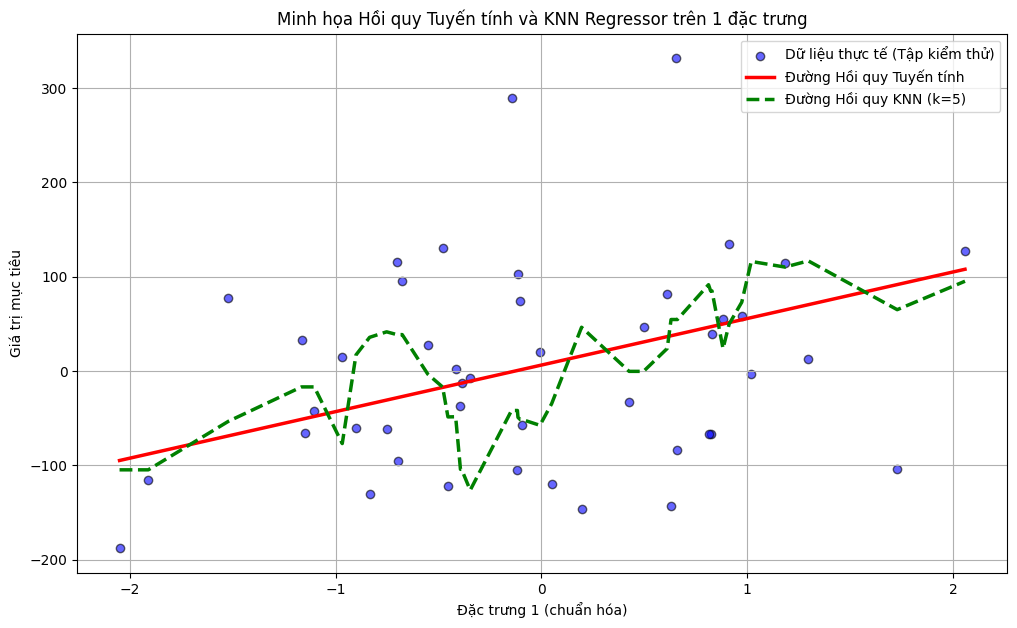

In [8]:
# Lấy 1 đặc trưng đầu tiên để trực quan hóa
X_train_1d = X_train_reg[:, 0].reshape(-1, 1) # Reshape thành cột vector
X_test_1d = X_test_reg[:, 0].reshape(-1, 1)

# Huấn luyện lại Linear Regression với 1 đặc trưng
lr_model_1d = LinearRegressionModel()
lr_model_1d.fit(X_train_1d, y_train_reg)
if lr_model_1d.weights is not None:
    y_pred_lr_1d_on_test = lr_model_1d.predict(X_test_1d)

    # Sắp xếp để vẽ đường thẳng mượt hơn
    sort_indices_lr = np.argsort(X_test_1d[:,0])
    X_test_1d_sorted_lr = X_test_1d[sort_indices_lr]
    y_pred_lr_1d_sorted = y_pred_lr_1d_on_test[sort_indices_lr]


# Huấn luyện lại KNN Regressor với 1 đặc trưng
knn_reg_model_1d = KNNRegressor(k=5)
knn_reg_model_1d.fit(X_train_1d, y_train_reg)
y_pred_knn_1d_on_test = knn_reg_model_1d.predict(X_test_1d)

# Sắp xếp để vẽ đường KNN mượt hơn
sort_indices_knn = np.argsort(X_test_1d[:,0])
X_test_1d_sorted_knn = X_test_1d[sort_indices_knn]
y_pred_knn_1d_sorted = y_pred_knn_1d_on_test[sort_indices_knn]


# Vẽ đồ thị
plt.figure(figsize=(12, 7))
plt.scatter(X_test_1d, y_test_reg, color='blue', label='Dữ liệu thực tế (Tập kiểm thử)', alpha=0.6, edgecolor='k')

if lr_model_1d.weights is not None:
    plt.plot(X_test_1d_sorted_lr, y_pred_lr_1d_sorted, color='red', linewidth=2.5, label='Đường Hồi quy Tuyến tính')

plt.plot(X_test_1d_sorted_knn, y_pred_knn_1d_sorted, color='green', linewidth=2.5, linestyle='--', label='Đường Hồi quy KNN (k=5)')

plt.xlabel("Đặc trưng 1 (chuẩn hóa)")
plt.ylabel("Giá trị mục tiêu")
plt.title("Minh họa Hồi quy Tuyến tính và KNN Regressor trên 1 đặc trưng")
plt.legend()
plt.grid(True)
plt.show()

## 6. Nhận xét và Kết luận

-   **Hồi quy Tuyến tính:**
    * Đã xây dựng thành công thuật toán Hồi quy Tuyến tính từ đầu sử dụng Normal Equation.
    * Mô hình này tìm một đường (hoặc siêu phẳng) tuyến tính phù hợp nhất với dữ liệu.
    * Giả định rằng có một mối quan hệ tuyến tính giữa các đặc trưng và biến mục tiêu.

-   **KNN Regressor:**
    * Đã xây dựng thành công thuật toán KNN cho bài toán hồi quy.
    * Dự đoán dựa trên giá trị trung bình của các láng giềng gần nhất, không giả định về dạng của mối quan hệ.
    * Có thể linh hoạt hơn Hồi quy Tuyến tính nếu mối quan hệ là phi tuyến, nhưng nhạy cảm với việc chọn $k$ và nhiễu.

-   **So sánh chung:**
    * Cả hai thuật toán đều có thể được sử dụng để dự đoán giá trị liên tục.
    * Hồi quy Tuyến tính đơn giản, dễ diễn giải nhưng có thể không hiệu quả nếu mối quan hệ thực tế không tuyến tính.
    * KNN Regressor linh hoạt hơn nhưng chi phí tính toán khi dự đoán cao hơn và cần lựa chọn $k$ cẩn thận.
    * Việc chuẩn hóa dữ liệu là quan trọng, đặc biệt với KNN.

-   **Lưu ý về Dataset:** Kết quả và đồ thị minh họa ở đây là trên bộ dữ liệu mẫu được tạo ra. Khi nhóm thay thế bằng bộ dữ liệu tự thu thập (ví dụ: ước lượng khối lượng xoài), các bước tiền xử lý, huấn luyện và đánh giá cần được thực hiện lại tương ứng.